# Кластеризация точек продаж аптечной сети

Задача: разбить точки сети на сегменты, внутри которых точки похожи по трём независимым признакам:

1. **размер** - площадь торгового зала и «весовая категория» по деньгам (выручка и число чеков);
2. **ценовое позиционирование** - какую долю выручки точка делает в дешёвом, среднем и дорогом товаре своей
   подкатегории (с приведением цены к одной дозе);
3. **ассортиментный профиль** - на какие категории товара точка «заточена».

Из трёх разбиений автоматически собирается итоговый сегмент с человекочитаемым названием. Дальше под каждый
сегмент строится своя ассортиментная матрица - это соседний проект
[`../Скоринг и выбор ассортиментной матрицы`](../Скоринг%20и%20выбор%20ассортиментной%20матрицы).

**Про данные.** В оригинале расчёт шёл по корпоративному DWH и был разнесён на 6 ноутбуков с ручным сведением
результатов в Excel. Здесь - один ноутбук на **синтетических данных** из общей базы
[`../synthetic_data`](../synthetic_data): справочник лекарств взят из открытого реестра ЖНВЛП (ГРЛС), точки,
чеки и остатки сгенерированы. Цифры не отражают реальный бизнес, но алгоритм, SQL-фильтры и логика
шагов - те же. Отличия от оригинальной методики перечислены в конце.

## Импорт библиотек и параметры

In [1]:
import os
import textwrap

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

pd.options.display.max_columns = 100
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110

In [2]:
# База с синтетическими данными (общая для проектов портфолио)
DB_PATH = os.environ.get('SYNTH_DB', '../synthetic_data/synthetic_projects.duckdb')

MIN_STORE_AGE_MONTHS = 6          # точка должна проработать не меньше полугода к концу периода
OPTICS_TRADE_POINT_TYPE_ID = 4    # формат «оптика» кластеризуется отдельно, здесь исключается
EXCLUDED_SALE_TYPES = ('Опт', 'Маркетплейс')  # не розница и заказы через сторонние агрегаторы
MIN_SHELF_LIFE_MONTHS = 6         # уценённый товар с коротким сроком годности искажает цены

PRICE_TIER_LOW_PERCENTILE = 30    # границы low / medium / high внутри подкатегории
PRICE_TIER_HIGH_PERCENTILE = 70

# Диапазоны, в которых число кластеров выбирается автоматически («локоть» по ускорению расстояний Ward)
K_RANGE_SIZE = (3, 7)
K_RANGE_PRICE = (3, 7)
K_RANGE_ASSORT = (4, 10)

# Смежные категории, которые для ассортиментного анализа объединяются (как в оригинальном расчёте)
MERGE_CATEGORIES = {'Сердечно-сосудистая система': 'Сердце и кровь', 'Кровь и кроветворение': 'Сердце и кровь'}
# Категории с долей в выручке сети меньше порога объединяются в «Прочие препараты»: после стандартизации
# их случайный шум весил бы наравне с крупными категориями
MIN_CATEGORY_SHARE = 0.02

SEED = 2023

## Функции

In [3]:
con = duckdb.connect(DB_PATH)


def query(sql: str, params=None) -> pd.DataFrame:
    """SQL к базе с синтетикой. В оригинале здесь было чтение из корпоративного DWH через ODBC."""
    return con.execute(sql, params or []).df()


def choose_k(Z, k_min: int, k_max: int) -> int:
    """Автоматический выбор числа кластеров по «локтю» дендрограммы: берём k, при котором ускорение
    роста расстояния слияния (вторая разность) максимально. В оригинале тот же график смотрели глазами
    и число кластеров вписывали вручную."""
    last = Z[-(k_max + 1):, 2]
    acceleration = np.diff(last, 2)[::-1]           # индекс 0 соответствует k = 2
    ks = np.arange(2, 2 + len(acceleration))
    mask = (ks >= k_min) & (ks <= k_max)
    return int(ks[mask][np.argmax(acceleration[mask])])


def ward_clusters(X: pd.DataFrame, k_range, title: str, order_by: pd.Series = None, prefix: str = ''):
    """Иерархическая кластеризация Ward + автоматический выбор k + график локтя.
    Номера кластеров переупорядочиваются по среднему `order_by` (1 - наименьшее), чтобы номер что-то значил."""
    Z = shc.linkage(X, method='ward')
    k = choose_k(Z, *k_range)
    labels = shc.fcluster(Z, k, criterion='maxclust')

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
    shc.dendrogram(Z, truncate_mode='lastp', p=k, ax=axes[0], color_threshold=Z[-(k - 1), 2])
    axes[0].set_title(f'{title}: дендрограмма, {k} кластеров')
    axes[0].set_xlabel('размер кластера (число точек)')
    last = Z[-12:, 2][::-1]
    axes[1].plot(np.arange(1, len(last) + 1), last, marker='o', label='расстояние слияния')
    axes[1].plot(np.arange(2, len(last) - 1 + 1), np.diff(Z[-12:, 2], 2)[::-1], marker='o', label='ускорение')
    axes[1].axvline(k, color='crimson', ls=':', lw=2)
    axes[1].set_title('Выбор числа кластеров'); axes[1].set_xlabel('число кластеров'); axes[1].legend()
    plt.tight_layout(); plt.show()

    labels = pd.Series(labels, index=X.index)
    if order_by is not None:
        rank = order_by.groupby(labels).mean().rank(method='first').astype(int)
        labels = labels.map(rank)
    return labels.map(lambda c: f'{prefix}{c}')


def annotate_heatmap(ax, values, fmt):
    """Подписи ячеек тепловой карты (в seaborn 0.12 с matplotlib 3.8+ встроенные подписи выводятся только
    в первой строке, поэтому ставим их сами)."""
    vmax = np.nanmax(values) if np.size(values) else 1
    for (i, j), v in np.ndenumerate(values):
        if v == 0 or np.isnan(v):
            continue
        ax.text(j + .5, i + .5, format(int(v) if fmt == 'd' else v, fmt), ha='center', va='center', fontsize=9,
                color='white' if v > 0.6 * vmax else '#222')


def plot_crosstab(a: pd.Series, b: pd.Series, title: str, normalize=False, figsize=None, fmt='d'):
    """Тепловая карта пересечения двух разбиений: сколько точек в каждой паре кластеров."""
    ct = pd.crosstab(a, b, normalize='index' if normalize else False)
    if normalize:
        fmt = '.0%'
    figsize = figsize or (1.1 * ct.shape[1] + 3, 0.5 * ct.shape[0] + 1.6)
    plt.figure(figsize=figsize)
    ax = sns.heatmap(ct, cmap='YlGnBu', cbar=False, linewidths=.5)
    annotate_heatmap(ax, ct.to_numpy(dtype=float), fmt)
    plt.title(title); plt.xlabel(b.name); plt.ylabel(a.name)
    plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

## 1. Отбор действующих точек

Закрытые точки и точки младше полугода (без представительной истории продаж) в кластеризацию не идут.
Формат «оптика» - отдельный тип точки со своим ассортиментом, его сегментируют отдельно.

In [4]:
period = query("SELECT MIN(Date) AS date_from, MAX(Date) AS date_to FROM pharmacy.cheques").iloc[0]
DATE_FROM, DATE_TO = pd.Timestamp(period.date_from), pd.Timestamp(period.date_to)

stores_all = query("""
    SELECT TradePointId, TradePointCode, BrandName, BusinessUnit, TradePointTypeId, TradePointType,
           TradeSquare, Layout, Location, OpenDate, CloseDate, IsVip, IsDiscounter, CurrentCategory
    FROM pharmacy.stores
""")
stores_all['age_months'] = (DATE_TO - stores_all['OpenDate']).dt.days / 30.44

is_open = stores_all['CloseDate'].isna() | (stores_all['CloseDate'] > DATE_TO)
is_mature = stores_all['age_months'] >= MIN_STORE_AGE_MONTHS
is_pharmacy = stores_all['TradePointTypeId'] != OPTICS_TRADE_POINT_TYPE_ID
stores = stores_all[is_open & is_mature & is_pharmacy].set_index('TradePointId')

print(f'Период чеков: {DATE_FROM:%d.%m.%Y} - {DATE_TO:%d.%m.%Y}')
print(f'Точек в справочнике: {len(stores_all)}; закрыты: {(~is_open).sum()}, младше {MIN_STORE_AGE_MONTHS} мес.: '
      f'{(is_open & ~is_mature).sum()}, оптика: {(is_open & is_mature & ~is_pharmacy).sum()}')
print(f'В кластеризацию идут: {len(stores)} аптек')

Период чеков: 02.03.2026 - 29.03.2026
Точек в справочнике: 260; закрыты: 14, младше 6 мес.: 6, оптика: 6
В кластеризацию идут: 234 аптек


## 2. Чеки с бизнес-фильтрами

Те же фильтры, что в оригинальном SQL к DWH: без опта и заказов через сторонние маркетплейсы, без уценённого
товара с остаточным сроком годности меньше 6 месяцев, без нетоварных позиций (пакеты, доставка). Ниже видно,
сколько строк отсекает каждый фильтр.

In [5]:
funnel = query(f"""
    SELECT
        COUNT(*)                                                             AS "все строки чеков",
        COUNT(*) FILTER (WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES})      AS "без опта и маркетплейсов",
        COUNT(*) FILTER (WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
                           AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}) AS "+ без уценки по сроку",
        COUNT(*) FILTER (WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
                           AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}
                           AND p.product_class <> 'Нетоварные позиции')      AS "+ без нетоварных позиций"
    FROM pharmacy.cheques c
    JOIN pharmacy.products p USING (apCode)
""").T.rename(columns={0: 'строк'})
funnel

,строк
все строки чеков,576250
без опта и маркетплейсов,547309
+ без уценки по сроку,530786
+ без нетоварных позиций,519643


In [6]:
df = query(f"""
    SELECT c.ChequeId, c.TradePointId, c.apCode, c.Date, c.Amount, c.Sum_Price, c.Sum_Fact, c.Sum_Purch,
           p.category, p.subcategory, p.doses_in_pack, p.pack_ambiguous, p.is_own_brand
    FROM pharmacy.cheques c
    JOIN pharmacy.products p USING (apCode)
    WHERE c.SaleType NOT IN {EXCLUDED_SALE_TYPES}
      AND c.ShelfLifeMonths >= {MIN_SHELF_LIFE_MONTHS}
      AND p.product_class <> 'Нетоварные позиции'
      AND c.Date BETWEEN ? AND ?
""", [DATE_FROM, DATE_TO])
df = df[df['TradePointId'].isin(stores.index)]
print(f'{len(df):,} строк, {df.ChequeId.nunique():,} чеков, {df.apCode.nunique():,} товаров, '
      f'{df.TradePointId.nunique()} точек')

502,243 строк, 269,783 чеков, 3,197 товаров, 234 точек


## 3. Размер точки

Два взгляда на размер: физический формат (площадь торгового зала) и «весовая категория» по деньгам
(выручка до скидок и число чеков). Их расхождение само по себе информативно: большая площадь со слабыми
продажами или маленькая точка с огромным трафиком - кандидаты на отдельное управленческое решение.

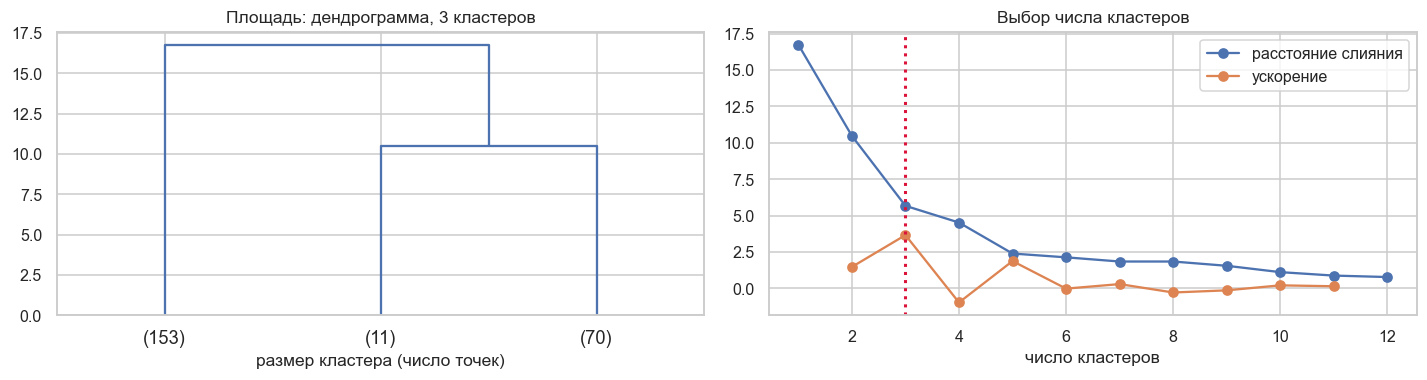

In [7]:
size = df.groupby('TradePointId').agg(Revenue=('Sum_Price', 'sum'), ChequeCount=('ChequeId', 'nunique'))
size = size.join(stores[['TradeSquare']])
size['mean_purch'] = size.Revenue / size.ChequeCount

X_square = pd.DataFrame(StandardScaler().fit_transform(size[['TradeSquare']]), index=size.index)
size['ID_size_square'] = ward_clusters(X_square, K_RANGE_SIZE, 'Площадь', order_by=size.TradeSquare, prefix='П')

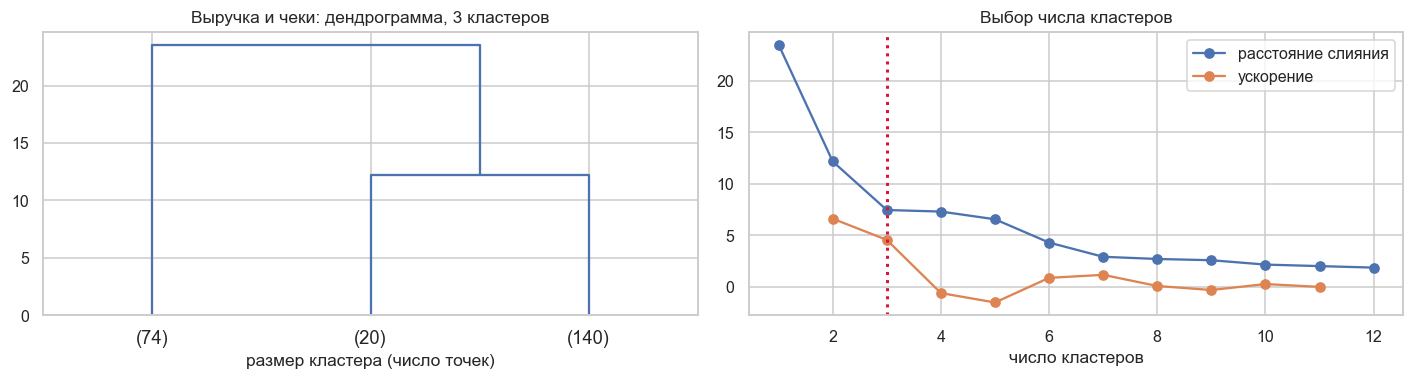

In [8]:
# выручка и чеки сильно скошены вправо - кластеризуем в логарифмах (в оригинале - без логарифма)
X_money = pd.DataFrame(StandardScaler().fit_transform(np.log(size[['Revenue', 'ChequeCount']])), index=size.index)
size['ID_size_rev_cheque'] = ward_clusters(X_money, K_RANGE_SIZE, 'Выручка и чеки',
                                           order_by=size.Revenue, prefix='В')

C:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


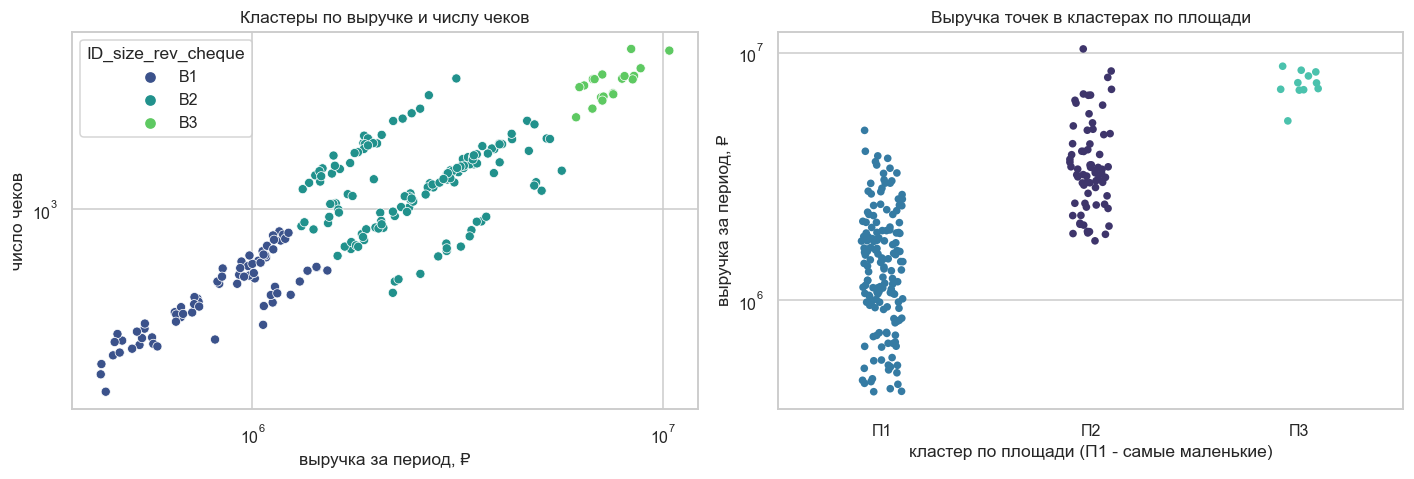

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(data=size, x='Revenue', y='ChequeCount', hue='ID_size_rev_cheque',
                hue_order=sorted(size.ID_size_rev_cheque.unique()), palette='viridis', ax=axes[0])
axes[0].set(xscale='log', yscale='log', title='Кластеры по выручке и числу чеков', xlabel='выручка за период, ₽',
            ylabel='число чеков')
sns.stripplot(data=size, x='ID_size_square', y='Revenue', order=sorted(size.ID_size_square.unique()),
              hue='ID_size_square', palette='mako', legend=False, size=5, ax=axes[1])
axes[1].set(yscale='log', title='Выручка точек в кластерах по площади', xlabel='кластер по площади (П1 - самые маленькие)',
            ylabel='выручка за период, ₽')
plt.tight_layout(); plt.show()

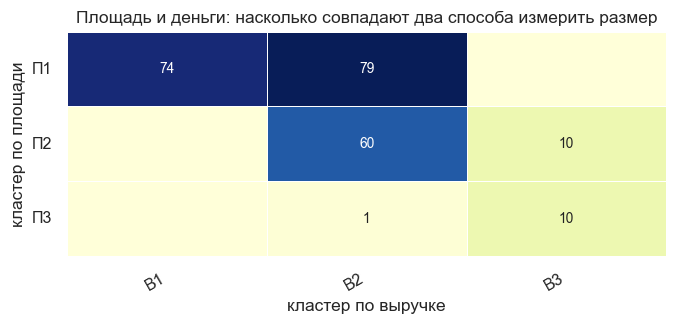

In [10]:
plot_crosstab(size.ID_size_square.rename('кластер по площади'), size.ID_size_rev_cheque.rename('кластер по выручке'),
              'Площадь и деньги: насколько совпадают два способа измерить размер')

## 4. Ценовое позиционирование

Идея в два шага:

1. **Разметить товары по ценовым уровням** `low` / `medium` / `high` внутри своей подкатегории - по 30-му и
   70-му перцентилю цены. «Дорого» и «дёшево» относительны: 500 ₽ за противовирусное и за пластырь - разные истории.
2. **Описать точку долями выручки** в каждом уровне и кластеризовать точки по этому профилю.

Цена приводится **к одной дозе**: иначе упаковка на 100 таблеток выглядит «дороже» упаковки на 10, хотя в
пересчёте на таблетку дешевле. Для штучных форм (таблетки, капсулы, суппозитории, саше) число доз берётся из
справочника, остальные считаются одной дозой. Позиции с неоднозначной фасовкой (наборы, комплекты) и товары
собственной торговой марки (у СТМ своя модель ценообразования, она сдвигала бы перцентили) исключаются.

In [11]:
# средняя цена упаковки: в приоритете остатки (устойчивее к разовым акциям), чеки - запасной источник
stock = query("""
    SELECT s.apCode, SUM(s.Sum_Purch) / SUM(s.Amount) AS mean_package
    FROM pharmacy.stock s
    GROUP BY s.apCode
""").set_index('apCode')['mean_package']
cheque_price = df.groupby('apCode').apply(lambda g: g.Sum_Purch.sum() / g.Amount.sum())

products = query("""
    SELECT apCode, name, category, subcategory, form_group, doses_in_pack, pack_ambiguous, is_own_brand
    FROM pharmacy.products WHERE product_class <> 'Нетоварные позиции'
""").set_index('apCode')
price = products[~products.pack_ambiguous & ~products.is_own_brand].copy()
price['mean_package'] = stock.reindex(price.index).fillna(cheque_price.reindex(price.index))
price = price.dropna(subset=['mean_package'])
price['doses'] = price.doses_in_pack.fillna(1)
price['price_per_dose'] = price.mean_package / price.doses
print(f'Цена есть у {len(price):,} товаров; из них {price.doses_in_pack.notna().sum():,} - штучные формы с пересчётом на дозу')

Цена есть у 2,975 товаров; из них 2,239 - штучные формы с пересчётом на дозу


C:\Users\User\AppData\Local\Temp\ipykernel_2776\2941327392.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cheque_price = df.groupby('apCode').apply(lambda g: g.Sum_Purch.sum() / g.Amount.sum())


In [12]:
pct = price.groupby('subcategory').agg(
    percentile_low=('price_per_dose', lambda x: np.percentile(x, PRICE_TIER_LOW_PERCENTILE)),
    percentile_high=('price_per_dose', lambda x: np.percentile(x, PRICE_TIER_HIGH_PERCENTILE)),
    nominal_high=('mean_package', lambda x: np.percentile(x, PRICE_TIER_HIGH_PERCENTILE)),
    nominal_low=('mean_package', lambda x: np.percentile(x, PRICE_TIER_LOW_PERCENTILE)),
    n=('price_per_dose', 'size'),
)
price = price.join(pct, on='subcategory')
price['price_tier'] = np.select([price.price_per_dose < price.percentile_low,
                                 price.price_per_dose <= price.percentile_high], ['low', 'medium'], 'high')

# Бизнес-правила оригинального расчёта (по номинальной цене упаковки, не за дозу):
# 1) разброс цен в подкатегории меньше 20% - делить на уровни бессмысленно, подкатегория исключается;
# 2) подкатегория в целом дешёвая - весь её товар считается low.
nominal_ratio = pct.nominal_high / pct.nominal_low - 1
too_narrow = nominal_ratio[nominal_ratio < 0.2].index
force_low = pct[(pct.nominal_high < 100) | ((pct.nominal_high < 150) & (nominal_ratio < 1))].index
price = price[~price.subcategory.isin(too_narrow)]
price.loc[price.subcategory.isin(force_low), 'price_tier'] = 'low'
print(f'Подкатегорий: {len(pct)}; исключено как слишком узкие: {len(too_narrow)}; целиком low: {len(force_low)}')
price.price_tier.value_counts(normalize=True).rename('доля товаров').to_frame()

Подкатегорий: 81; исключено как слишком узкие: 9; целиком low: 8


,доля товаров
price_tier,
medium,0.39
low,0.31
high,0.30


C:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


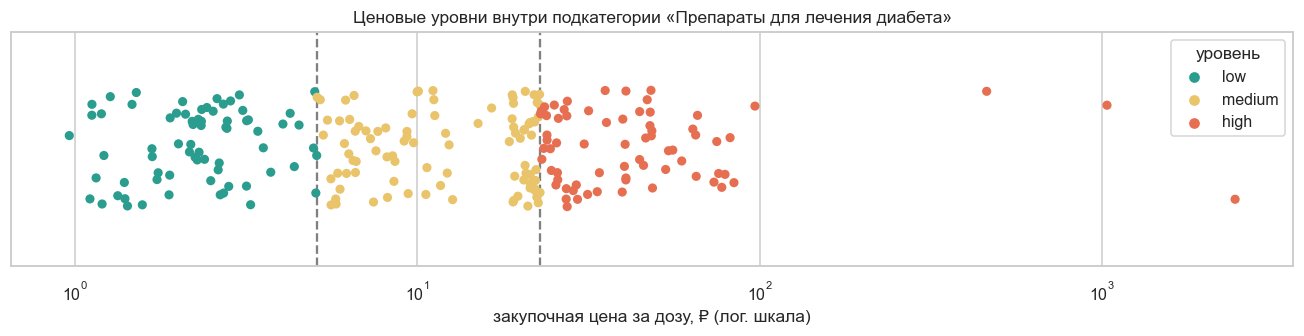

In [13]:
# пример разметки: одна подкатегория, цена за дозу и границы уровней
example = price.subcategory.value_counts().index[0]
ex = price[price.subcategory == example].sort_values('price_per_dose')
plt.figure(figsize=(12, 3.2))
sns.stripplot(data=ex, x='price_per_dose', hue='price_tier', hue_order=['low', 'medium', 'high'],
              palette={'low': '#2a9d8f', 'medium': '#e9c46a', 'high': '#e76f51'}, size=6, jitter=0.25)
for q in ('percentile_low', 'percentile_high'):
    plt.axvline(ex[q].iloc[0], color='grey', ls='--')
plt.xscale('log'); plt.xlabel('закупочная цена за дозу, ₽ (лог. шкала)')
plt.title(f'Ценовые уровни внутри подкатегории «{example}»'); plt.legend(title='уровень')
plt.tight_layout(); plt.show()

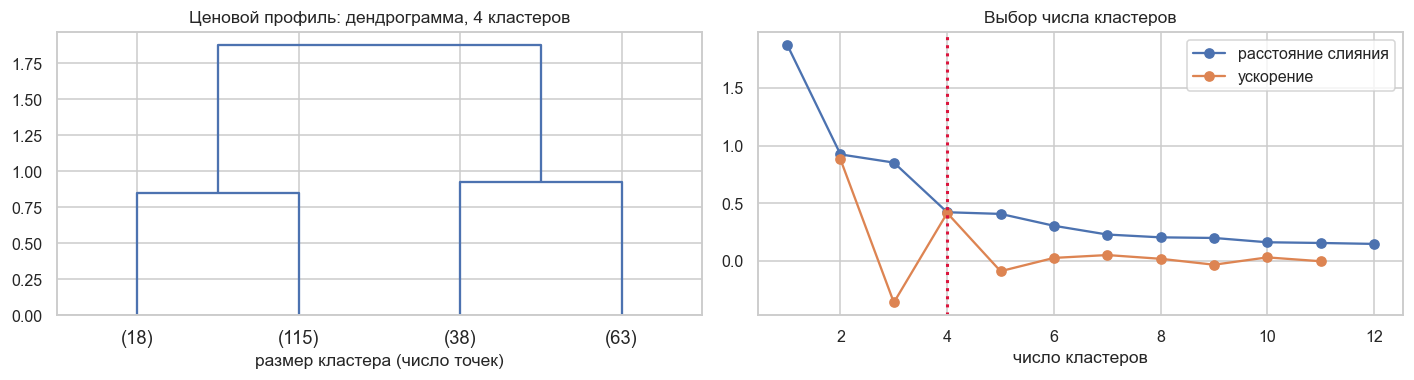

In [14]:
sales_tier = df.merge(price[['price_tier']], left_on='apCode', right_index=True)
price_profile = sales_tier.pivot_table(index='TradePointId', columns='price_tier', values='Sum_Purch',
                                       aggfunc='sum', fill_value=0)[['low', 'medium', 'high']]
price_profile = price_profile.div(price_profile.sum(axis=1), axis=0)
price_index = price_profile.high - price_profile.low      # >0 - точка смещена в дорогой товар

price_profile['ID_prices'] = ward_clusters(price_profile[['low', 'medium', 'high']], K_RANGE_PRICE, 'Ценовой профиль',
                                           order_by=price_index, prefix='Ц')

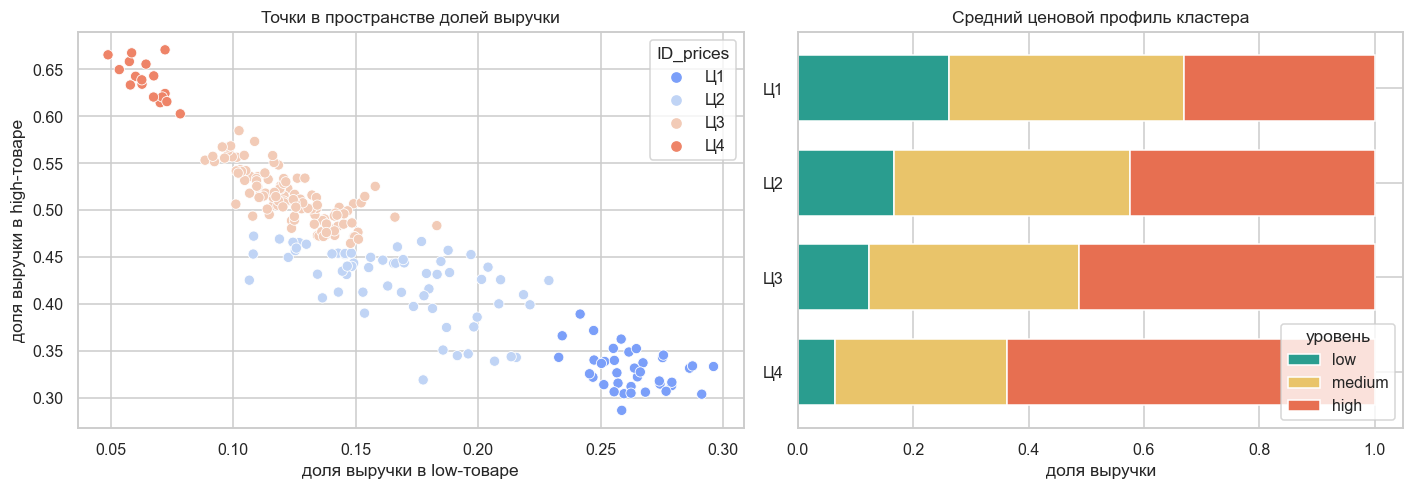

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1.1, 1]})
sns.scatterplot(data=price_profile, x='low', y='high', hue='ID_prices', palette='coolwarm',
                hue_order=sorted(price_profile.ID_prices.unique()), s=45, ax=axes[0])
axes[0].set(title='Точки в пространстве долей выручки', xlabel='доля выручки в low-товаре',
            ylabel='доля выручки в high-товаре')
means = price_profile.groupby('ID_prices')[['low', 'medium', 'high']].mean()
means.plot.barh(stacked=True, color=['#2a9d8f', '#e9c46a', '#e76f51'], ax=axes[1], width=0.7)
axes[1].set(title='Средний ценовой профиль кластера', xlabel='доля выручки', ylabel='')
axes[1].legend(title='уровень', loc='lower right'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

## 5. Ассортиментный профиль

Точка описывается вектором долей категорий в её собственной выручке - это «на что точка заточена», независимо
от её размера. Вектор стандартизуется и кластеризуется целиком (финальный вариант оригинального расчёта; перед
ним пробовались поочерёдные разбиения по каждой категории отдельно).

Объединены в «Прочие препараты»: Гормоны системного действия, Дерматология, Иммуномодуляторы и онкология, Оптика, Органы чувств, Прочие препараты


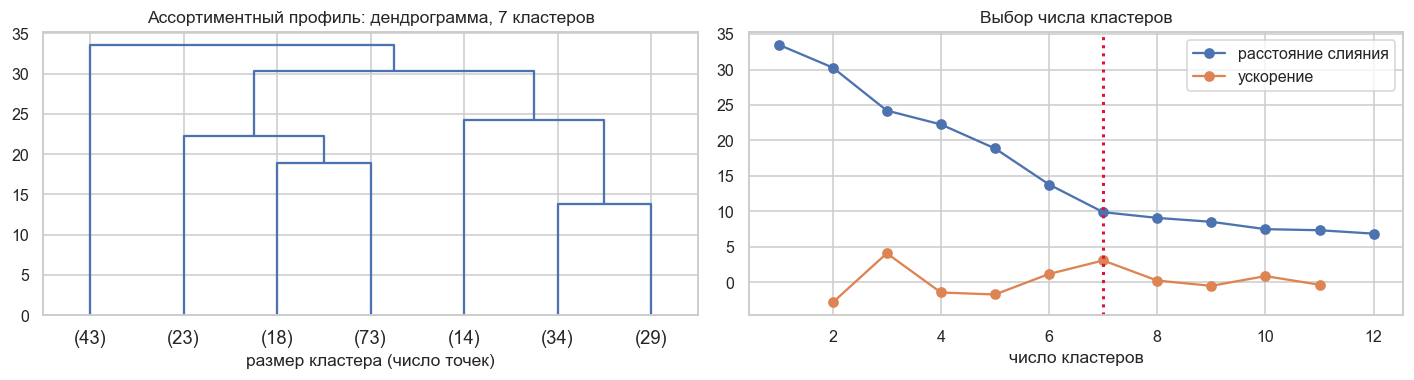

In [16]:
df['category_group'] = df.category.replace(MERGE_CATEGORIES)
share = df.groupby('category_group').Sum_Price.sum() / df.Sum_Price.sum()
small = share[share < MIN_CATEGORY_SHARE].index
df.loc[df.category_group.isin(small), 'category_group'] = 'Прочие препараты'
print('Объединены в «Прочие препараты»:', ', '.join(small))
assort = df.pivot_table(index='TradePointId', columns='category_group', values='Sum_Price', aggfunc='sum', fill_value=0)
assort = assort.div(assort.sum(axis=1), axis=0)
X_assort = pd.DataFrame(StandardScaler().fit_transform(assort), index=assort.index, columns=assort.columns)
ID_groups = ward_clusters(X_assort, K_RANGE_ASSORT, 'Ассортиментный профиль', prefix='А')
ID_groups = ID_groups.map(lambda c: f'А{int(c[1:]):02d}')

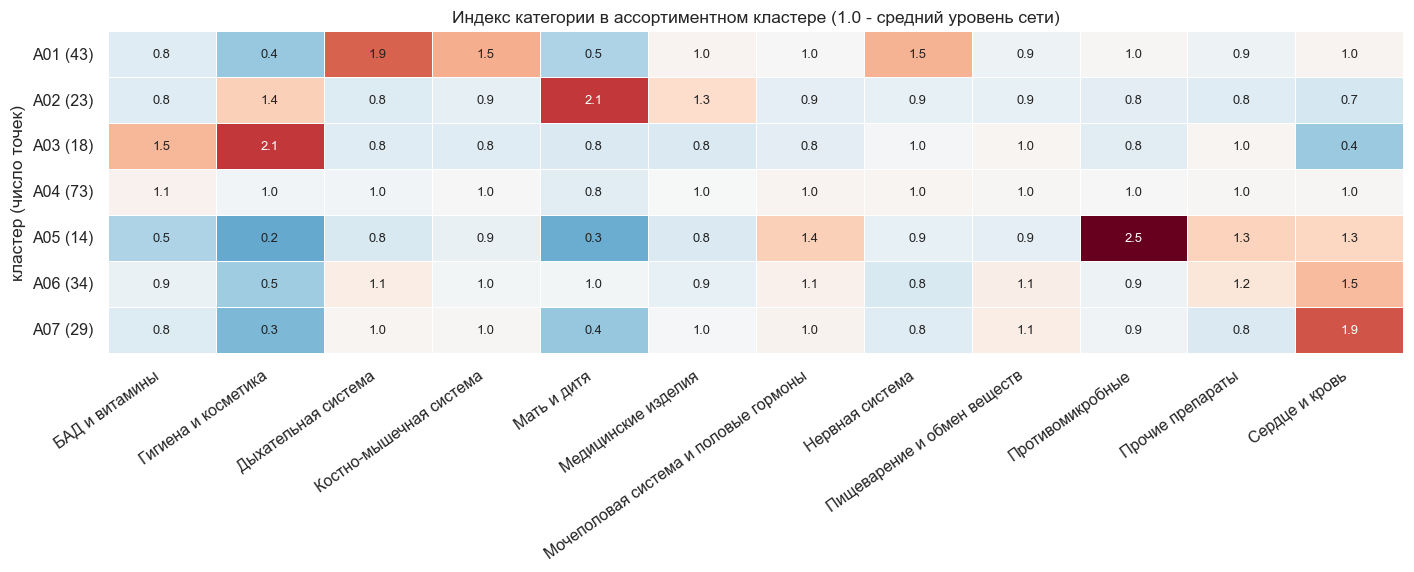

In [17]:
# индекс категории в кластере: доля в выручке кластера / доля в выручке сети (1.0 - как в среднем по сети)
network_share = df.groupby('category_group').Sum_Price.sum() / df.Sum_Price.sum()
cluster_share = assort.groupby(ID_groups).mean()
assort_index = cluster_share / network_share

plt.figure(figsize=(13, 0.45 * len(assort_index) + 2.2))
ax = sns.heatmap(assort_index, cmap='RdBu_r', center=1, vmin=0, vmax=2.5, cbar=False, linewidths=.5)
for (i, j), v in np.ndenumerate(assort_index.to_numpy()):
    ax.text(j + .5, i + .5, f'{v:.1f}', ha='center', va='center', fontsize=8.5,
            color='white' if abs(v - 1) > 0.9 else '#222')
plt.title('Индекс категории в ассортиментном кластере (1.0 - средний уровень сети)')
plt.xlabel(''); plt.ylabel('кластер (число точек)')
plt.yticks(np.arange(len(assort_index)) + .5, [f'{c} ({(ID_groups == c).sum()})' for c in assort_index.index], rotation=0)
plt.xticks(rotation=35, ha='right'); plt.tight_layout(); plt.show()

## 6. Итоговая сегментация - автоматически

В оригинале этот шаг был ручным: результаты трёх кластеризаций сводились в Excel, и сегментам давали названия
по пересечениям («Классическая аптека», «Аптека у дома», «ВИП-аптека»...). Здесь то же сведение
формализовано правилами:

- **размер**: кластер по выручке и чекам → уровень по тому, в какую треть распределения точек попадает его
  средняя выручка (малые / средние / крупные);
- **цена**: кластер по ценовому профилю → уровень по его среднему индексу `доля high - доля low`
  (эконом / медиум / премиум);
- **ассортимент**: категории, у которых индекс в кластере не ниже 1.3, - это «уклон» сегмента (не больше двух);
  если таких нет - профиль универсальный.

In [18]:
SHORT = {'Гигиена и косметика': 'косметика', 'Мать и дитя': 'мать и дитя', 'БАД и витамины': 'БАД',
         'Медицинские изделия': 'медизделия', 'Сердце и кровь': 'сердце и кровь', 'Оптика': 'оптика',
         'Противомикробные': 'антибиотики и противовирусные', 'Иммуномодуляторы и онкология': 'иммунология',
         'Гормоны системного действия': 'гормоны', 'Дыхательная система': 'простуда',
         'Нервная система': 'нервная система', 'Костно-мышечная система': 'опорно-двигательная',
         'Пищеварение и обмен веществ': 'ЖКТ и обмен веществ', 'Дерматология': 'дерматология',
         'Мочеполовая система и половые гормоны': 'урология и гинекология', 'Органы чувств': 'органы чувств'}
INDEX_THRESHOLD = 1.3


def level_by_terciles(cluster_values: pd.Series, store_values: pd.Series, names):
    lo, hi = store_values.quantile([1 / 3, 2 / 3])
    return cluster_values.map(lambda v: names[0] if v < lo else names[2] if v > hi else names[1])


seg = stores[['TradePointCode', 'BrandName', 'BusinessUnit', 'Layout', 'Location', 'IsVip', 'IsDiscounter',
              'CurrentCategory']].join(size).join(price_profile).join(ID_groups.rename('ID_groups'))

log_rev = np.log(seg.Revenue)
size_level = level_by_terciles(log_rev.groupby(seg.ID_size_rev_cheque).mean(), log_rev, ['Малые', 'Средние', 'Крупные'])
pidx = seg.high - seg.low
price_level = level_by_terciles(pidx.groupby(seg.ID_prices).mean(), pidx, ['эконом', 'медиум', 'премиум'])


def profile_name(row):
    top = row[row >= INDEX_THRESHOLD].sort_values(ascending=False).head(2)
    return 'универсальный' if top.empty else ', '.join(SHORT.get(c, c.lower()) for c in top.index)


assort_profile = assort_index.apply(profile_name, axis=1)

seg['Размер'] = seg.ID_size_rev_cheque.map(size_level)
seg['Цена'] = seg.ID_prices.map(price_level)
seg['Ассортимент'] = seg.ID_groups.map(assort_profile)
seg['Сегмент'] = seg['Размер'] + ' ' + seg['Цена'] + ' · ' + seg['Ассортимент']

pd.DataFrame({'уклон ассортимента': assort_profile, 'точек': ID_groups.value_counts()}).sort_index()

,уклон ассортимента,точек
А01,"простуда, опорно-двигательная",43
А02,"мать и дитя, косметика",23
А03,"косметика, БАД",18
А04,универсальный,73
А05,"антибиотики и противовирусные, урология и гине...",14
А06,сердце и кровь,34
А07,сердце и кровь,29


In [19]:
summary = seg.groupby('Сегмент').agg(
    точек=('TradePointCode', 'size'), площадь_м2=('TradeSquare', 'median'), выручка=('Revenue', 'median'),
    средний_чек=('mean_purch', 'median'), доля_high=('high', 'mean'), доля_low=('low', 'mean'),
).sort_values('выручка', ascending=False)
summary.style.format({'площадь_м2': '{:.0f}', 'выручка': '{:,.0f}', 'средний_чек': '{:,.0f}',
                      'доля_high': '{:.0%}', 'доля_low': '{:.0%}'}).background_gradient(subset=['выручка'], cmap='Blues')

,точек,площадь_м2,выручка,средний_чек,доля_high,доля_low
Сегмент,,,,,,
Крупные премиум · универсальный,14,217,"7,546,029","3,000",53%,11%
"Крупные премиум · мать и дитя, косметика",6,133,"6,768,695","2,445",55%,10%
"Средние премиум · мать и дитя, косметика",17,113,"3,826,826","2,393",55%,10%
"Средние премиум · косметика, БАД",18,82,"3,297,251","4,034",64%,7%
Средние эконом · универсальный,4,79,"3,148,860","2,294",46%,13%
Средние премиум · универсальный,52,99,"2,551,939","2,295",50%,13%
"Средние эконом · антибиотики и противовирусные, урология и гинекология",1,26,"2,221,140","2,343",47%,11%
Средние эконом · сердце и кровь,32,70,"1,868,988","1,133",33%,26%
"Средние премиум · антибиотики и противовирусные, урология и гинекология",3,35,"1,786,619","2,370",51%,13%


### Пересечения разбиений

Насколько три взгляда на точку согласуются друг с другом. Если бы ценовой кластер почти однозначно определялся
размером, отдельная ценовая кластеризация не несла бы новой информации.

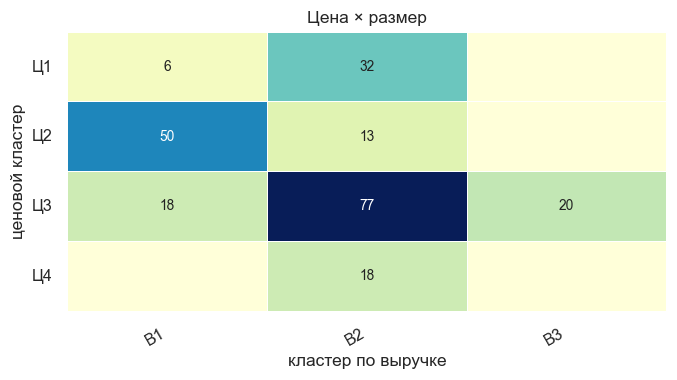

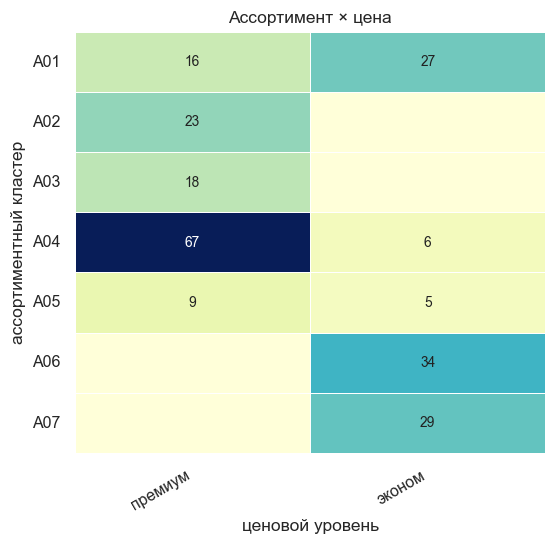

In [20]:
plot_crosstab(seg.ID_prices.rename('ценовой кластер'), seg.ID_size_rev_cheque.rename('кластер по выручке'),
              'Цена × размер')
plot_crosstab(seg.ID_groups.rename('ассортиментный кластер'), seg['Цена'].rename('ценовой уровень'),
              'Ассортимент × цена')

### Проверка сегментов на известных характеристиках точек

Правдоподобна ли сегментация: сходится ли она с тем, что про точку и так известно - бренд сети, локация,
формат выкладки (ОФТ - открытая форма торговли, ЗФТ - закрытая). Эти признаки в кластеризации не участвовали.

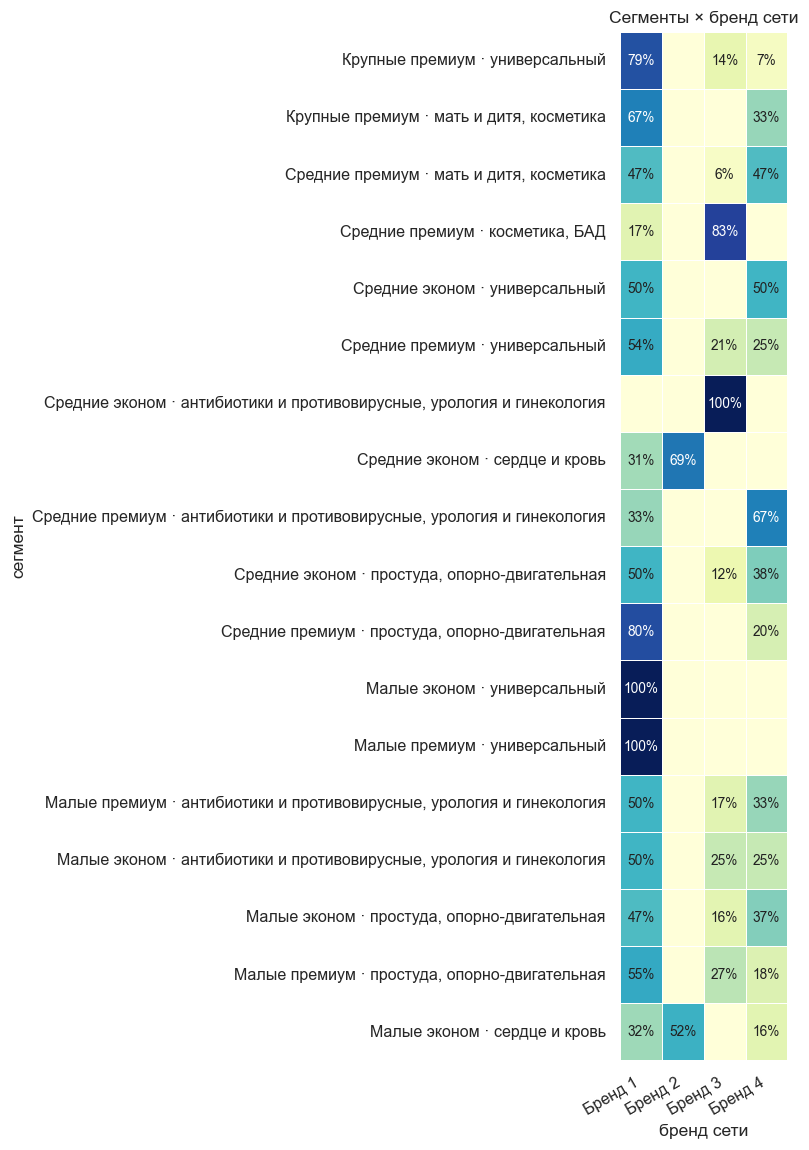

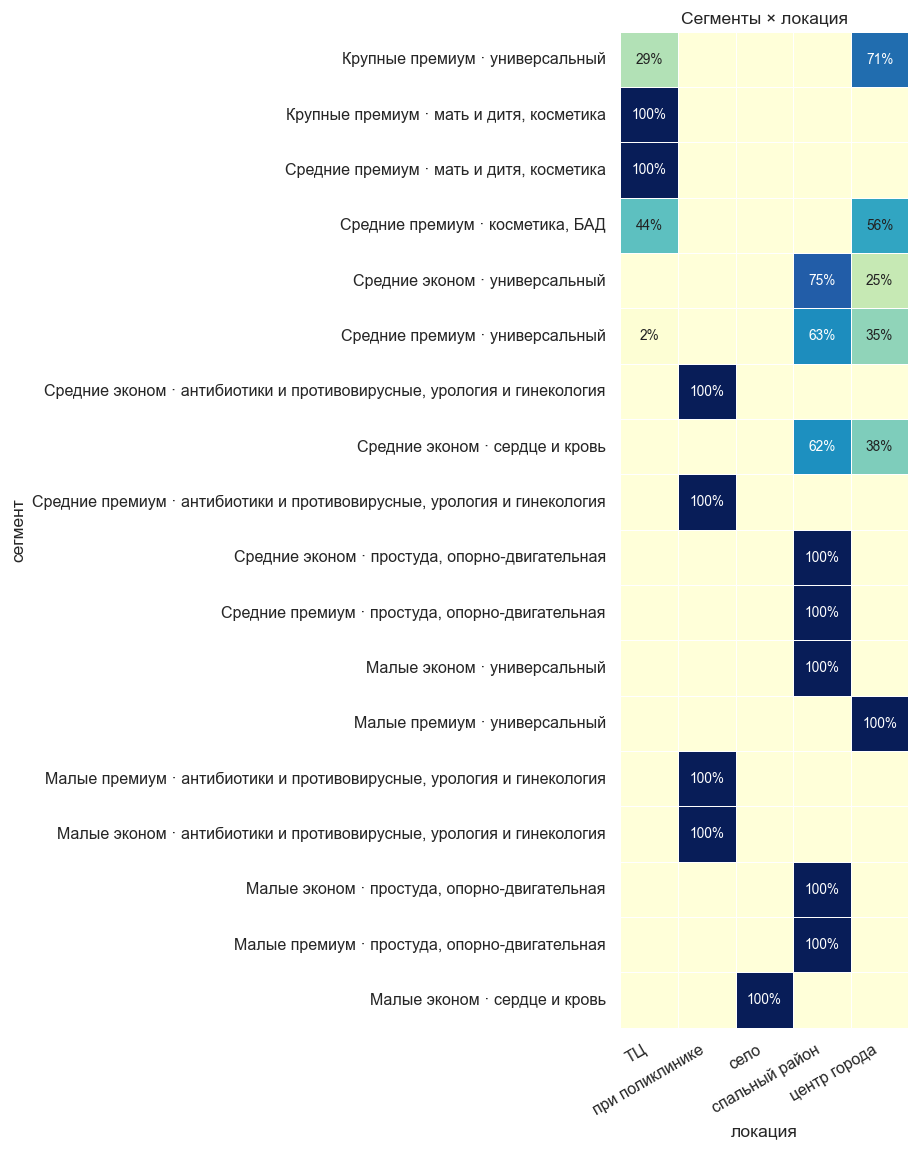

C:\Users\User\AppData\Local\Temp\ipykernel_2776\1092114648.py:67: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


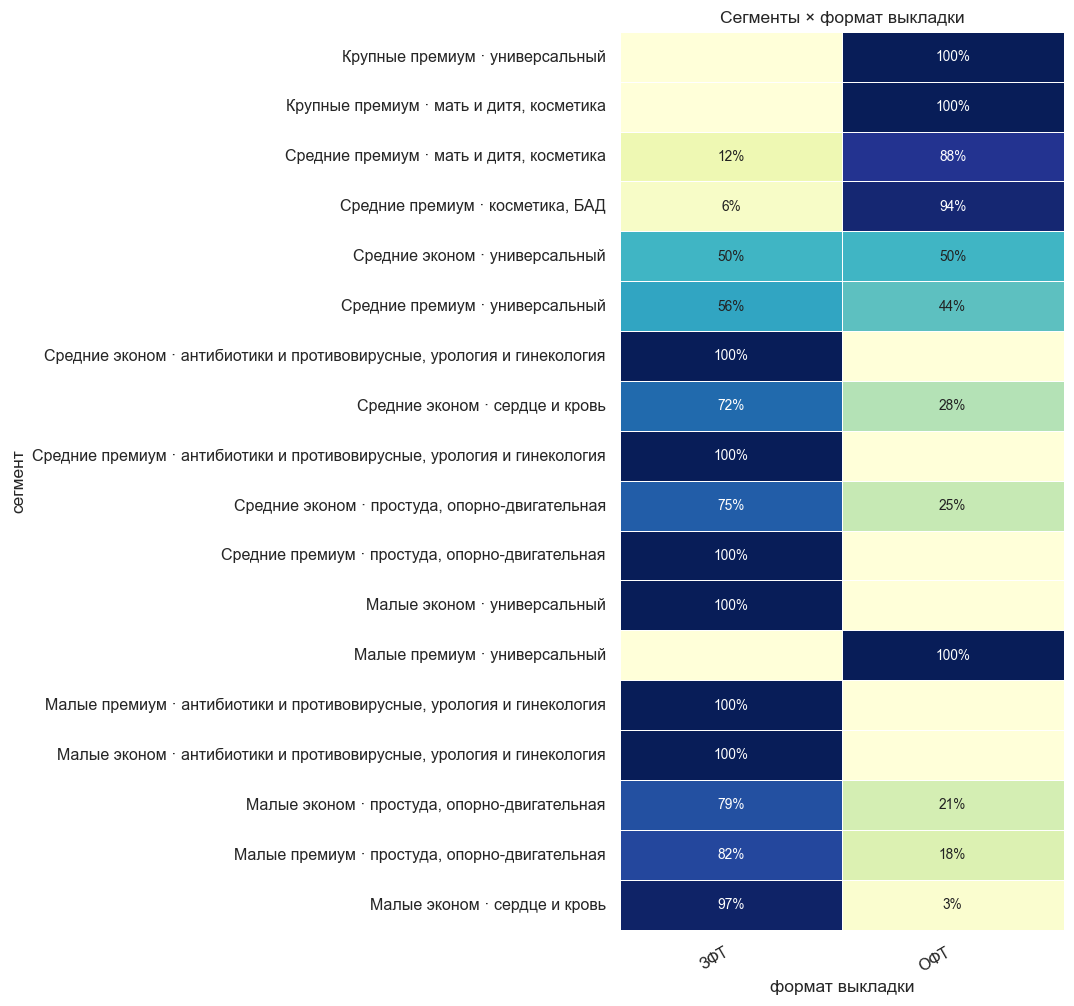

In [21]:
order = summary.index
for col, title in [('BrandName', 'Бренд сети'), ('Location', 'Локация'), ('Layout', 'Формат выкладки')]:
    plot_crosstab(seg['Сегмент'].rename('сегмент').astype(pd.CategoricalDtype(order, ordered=True)),
                  seg[col].rename(title.lower()), f'Сегменты × {title.lower()}', normalize=True)

### Проверка на заложенной структуре

Возможна только на синтетике: генератор данных заложил в каждую точку скрытый архетип (центральная аптека,
аптека у дома, дискаунтер и т.д.), а алгоритм его не видел. Если кластеризация работает, сегменты должны в
основном совпадать с архетипами. Мера совпадения - скорректированный индекс Рэнда (ARI): 0 - случайное
разбиение, 1 - полное совпадение.

ARI   ID_size_rev_cheque: 0.21
ARI            ID_prices: 0.32
ARI            ID_groups: 0.85
ARI              Сегмент: 0.76


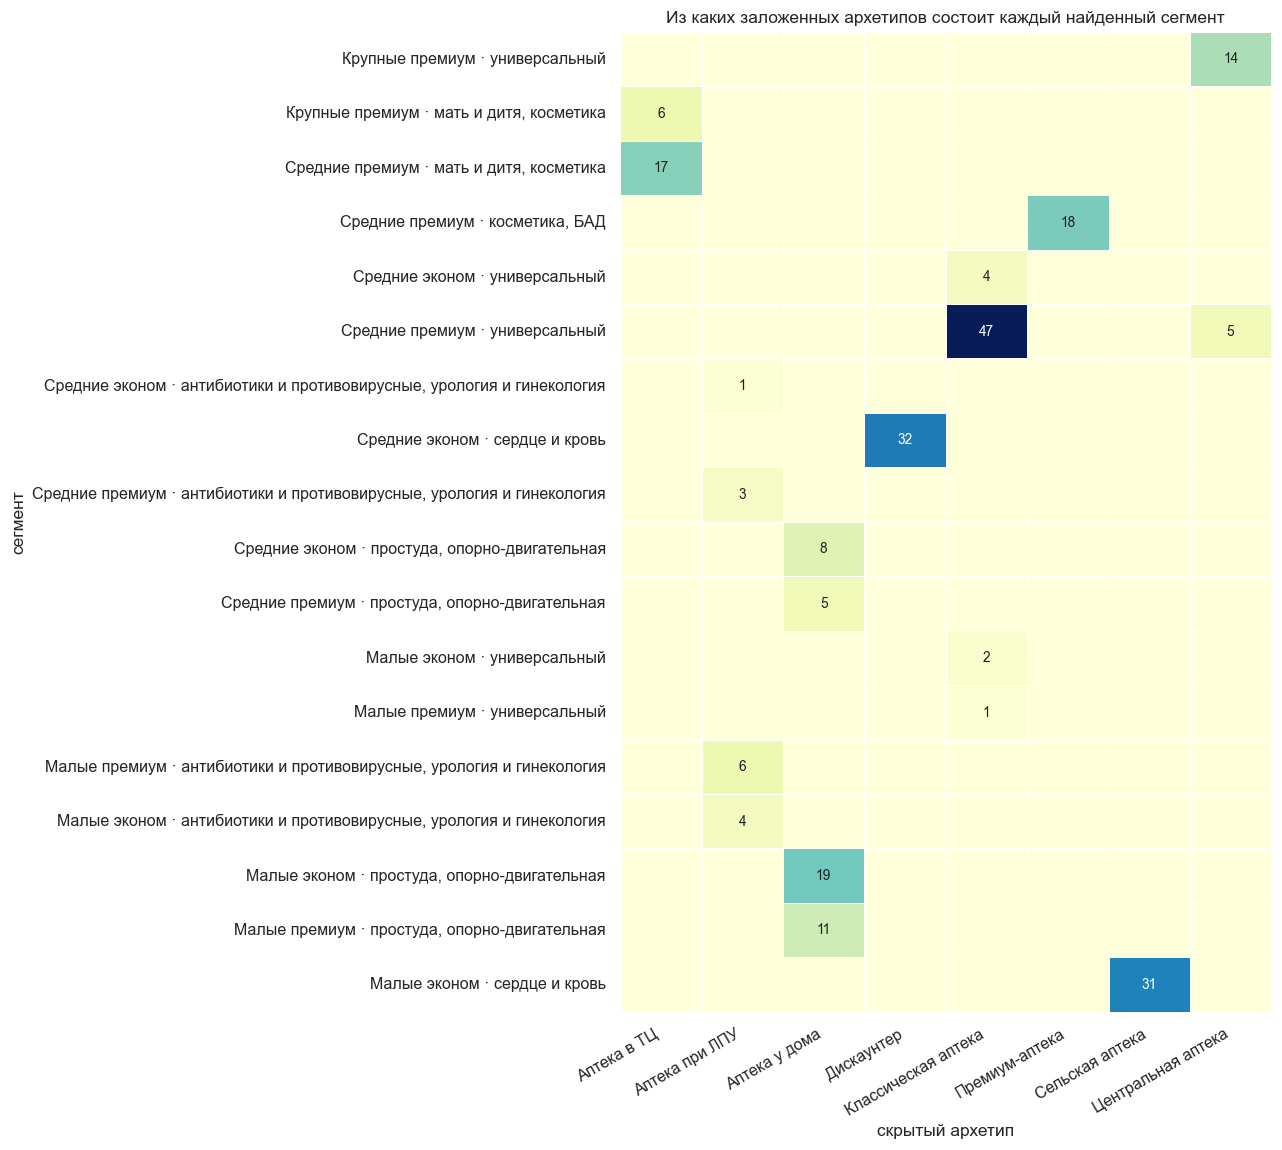

In [22]:
truth = query("SELECT TradePointId, archetype FROM pharmacy.store_archetypes").set_index('TradePointId').archetype
seg['Архетип (скрытый)'] = truth.reindex(seg.index)
for col in ['ID_size_rev_cheque', 'ID_prices', 'ID_groups', 'Сегмент']:
    print(f'ARI {col:>20}: {adjusted_rand_score(seg["Архетип (скрытый)"], seg[col]):.2f}')

plot_crosstab(seg['Сегмент'].rename('сегмент').astype(pd.CategoricalDtype(order, ordered=True)),
              seg['Архетип (скрытый)'].rename('скрытый архетип'),
              'Из каких заложенных архетипов состоит каждый найденный сегмент')

## 7. Сохранение результата

Сегменты точек и ценовые уровни товаров записываются в схему `results` той же базы - их использует следующий проект
([скоринг и выбор ассортиментной матрицы](../Скоринг%20и%20выбор%20ассортиментной%20матрицы)).

In [23]:
out = seg.reset_index()[['TradePointId', 'TradePointCode', 'ID_size_square', 'ID_size_rev_cheque', 'ID_prices',
                         'ID_groups', 'Размер', 'Цена', 'Ассортимент', 'Сегмент']]
out.columns = ['TradePointId', 'TradePointCode', 'size_square_cluster', 'size_money_cluster', 'price_cluster',
               'assortment_cluster', 'size_level', 'price_level', 'assortment_profile', 'segment']
con.execute('CREATE SCHEMA IF NOT EXISTS results')
con.register('out_df', out)
con.execute('CREATE OR REPLACE TABLE results.store_segments AS SELECT * FROM out_df')
con.unregister('out_df')

tiers = price.reset_index()[['apCode', 'subcategory', 'price_per_dose', 'price_tier']]
con.register('tiers_df', tiers)
con.execute('CREATE OR REPLACE TABLE results.product_price_tiers AS SELECT * FROM tiers_df')
con.unregister('tiers_df')
print(f'results.store_segments: {len(out)} точек, {out.segment.nunique()} сегментов')
print(f'results.product_price_tiers: {len(tiers):,} товаров')
con.close()

results.store_segments: 234 точек, 18 сегментов
results.product_price_tiers: 2,955 товаров


## Отличия от оригинального расчёта

- **6 ноутбуков → 1.** Отбор точек, три кластеризации, пересечения и итоговая сегментация идут одним прогоном.
- **Нет ручных шагов.** Число кластеров выбирается автоматически по тому же «локтю» дендрограммы, который в
  оригинале смотрели глазами; сведение трёх разбиений и названия сегментов строятся правилами (раздел 6),
  а не вручную в Excel.
- **Ценовая кластеризация - только вариант с приведением к дозе** (в оригинале было два ноутбука: без
  фасовки и с ней). Вместо отдельного файла-справочника фасовок число доз берётся из справочника товаров.
- **Исключённый производитель** оригинала (со своей моделью ценообразования) заменён на исключение товаров СТМ.
- **Мелкие категории (меньше 2% выручки сети) объединяются** перед ассортиментной кластеризацией.
- **Выручка и чеки кластеризуются в логарифмах** - на синтетике распределения сильно скошены.
- **Из ассортиментной части оставлен финальный вариант** (совместная кластеризация по всему вектору долей);
  промежуточные поочерёдные разбиения по отдельным категориям не показаны.
- **Добавлена проверка на заложенной структуре** (ARI) - на реальных данных такой «правильный ответ» недоступен.